<a href="https://colab.research.google.com/github/HitenBangarwa/HitenMLlab/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [2]:
df = pd.read_csv("/content/apartments_for_rent_classified_10K.csv",
                 sep=";",
                 encoding="latin1")

df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101.0,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1.577359e+09
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106.0,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1.577017e+09
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107.0,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1.577359e+09
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116.0,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1.576668e+09
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125.0,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1.577359e+09


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5261 entries, 0 to 5260
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             5261 non-null   int64  
 1   category       5261 non-null   object 
 2   title          5261 non-null   object 
 3   body           5261 non-null   object 
 4   amenities      3599 non-null   object 
 5   bathrooms      5235 non-null   float64
 6   bedrooms       5256 non-null   float64
 7   currency       5260 non-null   object 
 8   fee            5260 non-null   object 
 9   has_photo      5260 non-null   object 
 10  pets_allowed   3064 non-null   object 
 11  price          5260 non-null   float64
 12  price_display  5260 non-null   object 
 13  price_type     5260 non-null   object 
 14  square_feet    5260 non-null   float64
 15  address        3775 non-null   object 
 16  cityname       5218 non-null   object 
 17  state          5218 non-null   object 
 18  latitude

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,5.261000e+03,5235.000000,5256.000000,5260.000000,5260.000000,5253.000000,5253.000000,5.260000e+03
mean,5.633692e+09,1.011366,1.195205,1212.088973,624.327186,37.483899,-95.848271,1.575450e+09
std,6.442640e+07,0.100698,0.539887,558.075829,143.710448,5.774633,15.466028,3.455777e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.659899e+09,1.000000,1.000000,845.000000,540.750000,32.821200,-103.212100,1.576666e+09
50%,5.668613e+09,1.000000,1.000000,1068.000000,650.000000,38.791800,-95.434300,1.577359e+09
75%,5.668627e+09,1.000000,1.000000,1430.000000,735.000000,41.342600,-84.267100,1.577359e+09
max,5.668662e+09,2.500000,4.000000,5525.000000,829.000000,61.594000,-70.355900,1.577362e+09


In [4]:
df.isnull().sum()

,0
id,0
category,0
title,0
body,0
amenities,1662
bathrooms,26
bedrooms,5
currency,1
fee,1
has_photo,1


In [5]:
df_numeric = df.select_dtypes(include=[np.number])

df_numeric.head()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
0,5668626895,NaN,0.0,790.0,101.0,38.9057,-76.9861,1.577359e+09
1,5664597177,NaN,1.0,425.0,106.0,37.9680,-87.6621,1.577017e+09
2,5668626833,1.0,0.0,1390.0,107.0,38.8910,-77.0816,1.577359e+09
3,5659918074,1.0,0.0,925.0,116.0,47.6160,-122.3275,1.576668e+09
4,5668626759,NaN,0.0,880.0,125.0,38.8738,-77.1055,1.577359e+09


In [6]:
median_price = df_numeric["price"].median()

df_numeric["price_class"] = df_numeric["price"].apply(
    lambda x: 1 if x > median_price else 0
)

In [11]:
df_numeric_imputed = df_numeric.fillna(df_numeric.median())
X = df_numeric_imputed.drop(["price","price_class"],axis=1)
y = df_numeric_imputed["price_class"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = SVC(kernel="rbf")

model.fit(X_train_scaled,y_train)

SVC()

In [15]:
y_pred = model.predict(X_test_scaled)

In [16]:
print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Accuracy: 0.698005698005698

Confusion Matrix

[[453 105]
 [213 282]]

Classification Report

              precision    recall  f1-score   support

           0       0.68      0.81      0.74       558
           1       0.73      0.57      0.64       495

    accuracy                           0.70      1053
   macro avg       0.70      0.69      0.69      1053
weighted avg       0.70      0.70      0.69      1053



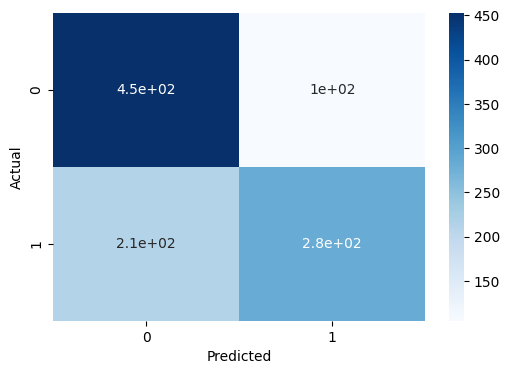

In [17]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()